In [2]:
import scanpy as sc
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import xgboost as xgboost
import joblib


In [3]:
home = "/project/Wellcome_Discovery/lturiano/GENESIS/"
data = "/project/Wellcome_Discovery/datashare/lturiano/data/"
sriva = "/project/Wellcome_Discovery/datashare/sriva/GENESIS/"

In [4]:
np.random.seed(42)

In [32]:
rna  = sc.read_h5ad(data+"rna_filt_aligned.h5ad")
gex  = sc.read_h5ad(data+"gex_filt_aligned.h5ad")
fake = sc.read_h5ad(data+"fake_RNA_VAE_UNET.h5ad")

In [33]:
# Load genes and label encoder from meta.joblib
meta = joblib.load(home + "meta.joblib")
genes = meta["genes"]

label_encoder = LabelEncoder()
label_encoder.classes_ = meta["label_classes"]   # must match training

# Load the trained XGBoost model
model_rna = xgb.XGBClassifier()
model_rna.load_model(home + "best_xgb_model.json")

In [34]:
genes

['ENSG00000159251',
 'ENSG00000156482',
 'ENSG00000118194',
 'ENSG00000219200',
 'ENSG00000138326',
 'ENSG00000122786',
 'ENSG00000223865',
 'ENSG00000272398',
 'ENSG00000149273',
 'ENSG00000167996',
 'ENSG00000152583',
 'ENSG00000158869',
 'ENSG00000173372',
 'ENSG00000198125',
 'ENSG00000107796',
 'ENSG00000163220',
 'ENSG00000111057',
 'ENSG00000078328',
 'ENSG00000110077',
 'ENSG00000175084',
 'ENSG00000231389',
 'ENSG00000164035',
 'ENSG00000132386',
 'ENSG00000165949',
 'ENSG00000204287',
 'ENSG00000204472',
 'ENSG00000177954',
 'ENSG00000159403',
 'ENSG00000102755',
 'ENSG00000170421',
 'ENSG00000105374',
 'ENSG00000166710',
 'ENSG00000143153',
 'ENSG00000077942',
 'ENSG00000166347',
 'ENSG00000143947',
 'ENSG00000204525',
 'ENSG00000212907',
 'ENSG00000101443',
 'ENSG00000174469',
 'ENSG00000065054',
 'ENSG00000206503',
 'ENSG00000196126',
 'ENSG00000172889',
 'ENSG00000112306',
 'ENSG00000119888',
 'ENSG00000139329',
 'ENSG00000019582',
 'ENSG00000196154',
 'ENSG00000108107',


In [35]:
label_encoder.classes_

array(['T cell', 'dendritic cell', 'duct cell', 'endothelial cell',
       'epithelial cell', 'fibroblast', 'lymphocyte', 'macrophage',
       'mural cell', 'myeloid cell', 'myocyte', 'neural cell'],
      dtype='<U16')

In [36]:
df_rna = pd.DataFrame(index   = rna.obs.index,
                      columns = genes,
                      data    = rna.X[:, rna.var_names.isin(genes)])

df_gex = pd.DataFrame(index   = gex.obs.index,
                      columns = genes,
                      data    = gex.X[:, gex.var_names.isin(genes)])

df_fake = pd.DataFrame(index   = fake.obs.index,
                       columns = genes,
                       data    = fake.X[:, fake.var_names.isin(genes)])

In [37]:
df_rna

,ENSG00000159251,ENSG00000156482,ENSG00000118194,ENSG00000219200,ENSG00000138326,ENSG00000122786,ENSG00000223865,ENSG00000272398,ENSG00000149273,ENSG00000167996,...,ENSG00000185883,ENSG00000171858,ENSG00000175061,ENSG00000198840,ENSG00000173991,ENSG00000240972,ENSG00000148671,ENSG00000129991,ENSG00000179344,ENSG00000271503
0,0.000000,0.0,2.421639,0.0,0.0,0.000000,2.626868,0.0,0.0,0.000000,...,4.252545,0.0,0.0,4.323022,0.0,0.000000,0.000000,0.000000,0.0,0.0
1,0.000000,0.0,0.000000,0.0,0.0,0.000000,2.451389,0.0,0.0,0.000000,...,0.000000,0.0,0.0,0.000000,0.0,0.000000,2.451389,0.000000,0.0,0.0
2,0.000000,0.0,0.000000,0.0,0.0,0.000000,2.975473,0.0,0.0,0.000000,...,0.000000,0.0,0.0,0.000000,0.0,0.000000,1.410942,0.000000,0.0,0.0
3,0.000000,0.0,1.598646,0.0,0.0,0.000000,1.598646,0.0,0.0,0.000000,...,4.519238,0.0,0.0,3.793456,0.0,0.000000,2.185226,0.000000,0.0,0.0
4,0.000000,0.0,1.278340,0.0,0.0,0.000000,3.468485,0.0,0.0,0.000000,...,0.000000,0.0,0.0,0.000000,0.0,0.000000,1.278340,0.000000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74712,0.000000,0.0,0.000000,0.0,0.0,3.002378,0.000000,0.0,0.0,0.000000,...,4.817029,0.0,0.0,3.651083,0.0,0.442105,0.000000,0.000000,0.0,0.0
74713,0.000000,0.0,0.000000,0.0,0.0,2.827374,0.000000,0.0,0.0,0.000000,...,3.371249,0.0,0.0,2.103444,0.0,0.000000,0.000000,0.000000,0.0,0.0
74714,0.000000,0.0,0.000000,0.0,0.0,2.343580,0.000000,0.0,0.0,2.324121,...,4.614589,0.0,0.0,3.350301,0.0,0.000000,0.000000,0.000000,0.0,0.0
74715,1.682446,0.0,0.000000,0.0,0.0,2.923309,0.000000,0.0,0.0,0.000000,...,3.912584,0.0,0.0,2.880892,0.0,0.000000,0.000000,2.267043,0.0,0.0


In [38]:
df_rna["cell_type"]  = label_encoder.transform(rna.obs["cell_type"].values.tolist())
df_gex["cell_type"]  = label_encoder.transform(gex.obs["cell_type"].values.tolist())
df_fake["cell_type"] = label_encoder.transform(rna.obs["cell_type"].values.tolist())

In [39]:
# Create train-test split (final evaluation set)
X_train_rna, X_test_rna, y_train_rna, y_test_rna = train_test_split(df_rna[df_rna.columns[:-1]],
                                                                    df_rna[df_rna.columns[-1]],
                                                                    test_size=0.15,
                                                                    random_state=42,
                                                                    stratify=df_rna[df_rna.columns[-1]]
                                                                    )

In [40]:
# Create train-test split (final evaluation set)
X_train_gex, X_test_gex, y_train_gex, y_test_gex = train_test_split(df_gex[df_gex.columns[:-1]],
                                                                    df_gex[df_gex.columns[-1]],
                                                                    test_size=0.15,
                                                                    random_state=42,
                                                                    stratify=df_gex[df_gex.columns[-1]]
                                                                    )

In [41]:
# Create train-test split (final evaluation set)
X_train_fake, X_test_fake, y_train_fake, y_test_fake = train_test_split(df_fake[df_fake.columns[:-1]],
                                                                        df_fake[df_fake.columns[-1]],
                                                                        test_size=0.15,
                                                                        random_state=42,
                                                                        stratify=df_fake[df_fake.columns[-1]]
                                                                        )

# Training and hyperparameter setting xgboost on scRNA

In [42]:
# # Define XGBoost classifier
# xgb_clf = xgboost.XGBClassifier(objective='multi:softprob',
#                                 num_class=len(label_encoder.classes_),
#                                 device="cpu",
#                                 random_state=42)

In [43]:
# # Hyperparameter grid
# param_grid = {'booster': ['gbtree', 'dart'],
#               'max_depth': [2, 4, 6],
#               'learning_rate': [0.01, 0.05, 0.1],
#               'n_estimators': [50, 100, 150],
#               'subsample': [0.6, 0.8, 1.0],
#               }

In [44]:
# # Cross-validation and hyperparameter tuning
# clf_cv = GridSearchCV(estimator=xgb_clf,
#                       param_grid=param_grid,
#                       scoring='accuracy',
#                       cv=5,
#                       verbose=1,
#                       n_jobs=8)

# clf_cv.fit(X_train_rna, y_train_rna)

In [45]:
# # Best hyperparameters
# print("Best hyperparameters:")
# print(clf_cv.best_params_)

# # Evaluate on final test set
# best_model = clf_cv.best_estimator_

In [46]:
# best_model.save_model('best_xgb_model.json')

# Performance evaluation on scRNA, scGEX, generated scGEX

In [ ]:
# y_pred_rna = model_rna.predict(X_train_rna)
# print(f'Accuracy: {accuracy_score(y_train_rna.values, y_pred_rna):.4f}')

Accuracy: 0.9961


In [ ]:
y_pred_rna = model_rna.predict(X_test_rna)

# Classification report
print("Classification Report:")
print(classification_report(y_test_rna.values, y_pred_rna, target_names=label_encoder.classes_))

Classification Report:
                  precision    recall  f1-score   support

          T cell       0.99      0.98      0.99      1043
  dendritic cell       0.87      0.88      0.87       305
       duct cell       0.86      0.61      0.71       260
endothelial cell       0.99      1.00      0.99      2014
 epithelial cell       0.93      0.97      0.95      1738
      fibroblast       0.99      0.98      0.99       734
      lymphocyte       0.98      0.98      0.98      1113
      macrophage       0.87      0.80      0.84       310
      mural cell       0.99      1.00      0.99      1500
    myeloid cell       0.98      0.99      0.99      1500
         myocyte       0.99      0.94      0.96       289
     neural cell       0.92      0.94      0.93       402

        accuracy                           0.97     11208
       macro avg       0.95      0.92      0.93     11208
    weighted avg       0.97      0.97      0.97     11208



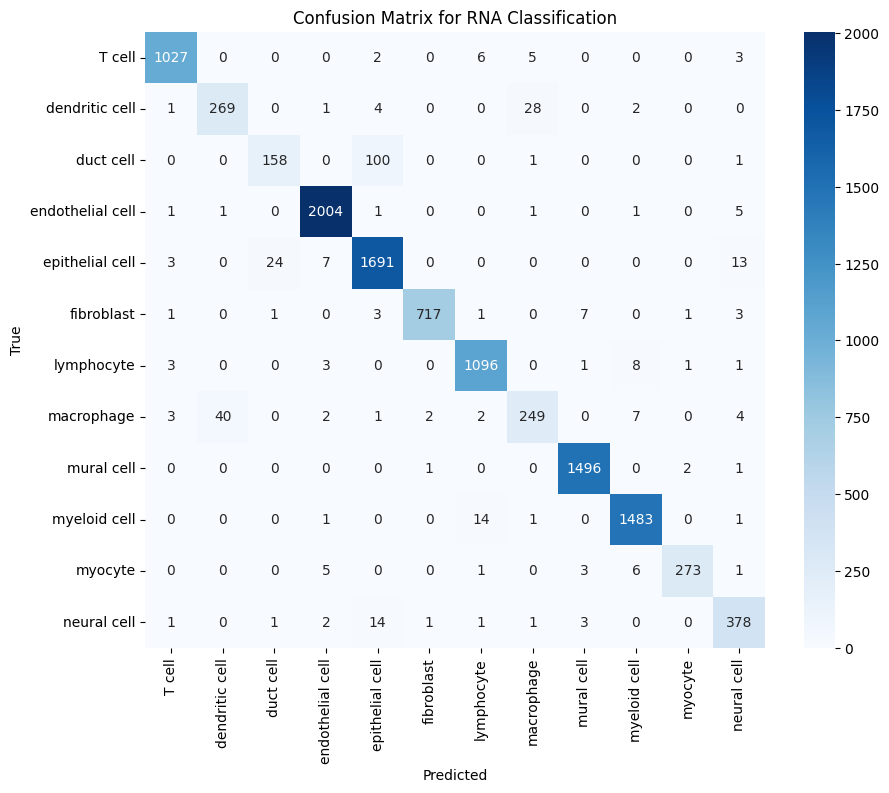

In [59]:
# Confusion matrix
cm = confusion_matrix(y_test_rna.values, y_pred_rna)

# Display confusion matrix as a heatmap
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for RNA Classification')
plt.show()

In [60]:
y_pred_gex = model_rna.predict(X_test_gex)

# Classification report
print("Classification Report for GEX:")
print(classification_report(y_test_gex.values, y_pred_gex, target_names=label_encoder.classes_))

Classification Report for GEX:
                  precision    recall  f1-score   support

          T cell       0.51      0.34      0.41      1043
  dendritic cell       0.38      0.16      0.23       305
       duct cell       0.71      0.12      0.21       260
endothelial cell       0.82      0.92      0.86      2014
 epithelial cell       0.61      0.67      0.64      1738
      fibroblast       0.68      0.76      0.72       734
      lymphocyte       0.66      0.50      0.56      1113
      macrophage       0.13      0.40      0.19       310
      mural cell       0.94      0.74      0.83      1500
    myeloid cell       0.85      0.04      0.08      1500
         myocyte       0.65      0.78      0.71       289
     neural cell       0.10      0.48      0.16       402

        accuracy                           0.56     11208
       macro avg       0.59      0.49      0.47     11208
    weighted avg       0.69      0.56      0.56     11208



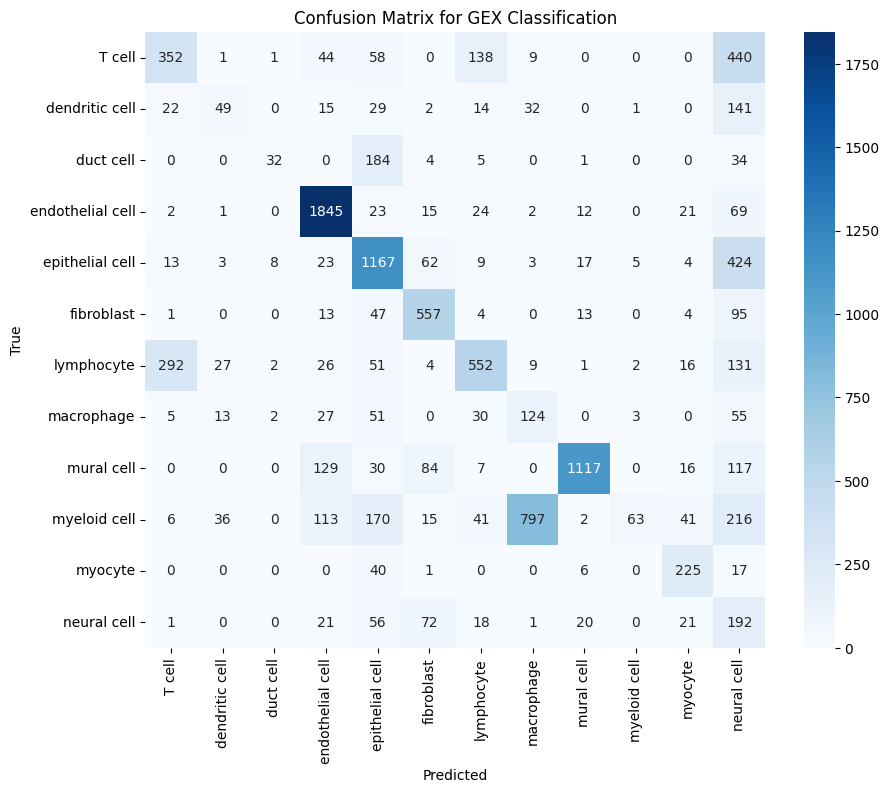

In [61]:
# Confusion matrix
cm = confusion_matrix(y_test_gex.values, y_pred_gex)
# Display confusion matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for GEX Classification')
plt.show()

In [55]:
y_pred_fake = model_rna.predict(X_test_fake)

# Classification report
print("Classification Report for GEX:")
print(classification_report(y_test_fake.values, y_pred_fake, target_names=label_encoder.classes_))

Classification Report for GEX:
                  precision    recall  f1-score   support

          T cell       0.84      0.18      0.29      1043
  dendritic cell       0.31      0.05      0.09       305
       duct cell       0.00      0.00      0.00       260
endothelial cell       0.61      0.77      0.68      2014
 epithelial cell       0.52      0.67      0.59      1738
      fibroblast       0.95      0.77      0.85       734
      lymphocyte       0.39      0.80      0.52      1113
      macrophage       0.17      0.22      0.19       310
      mural cell       0.99      0.24      0.39      1500
    myeloid cell       0.76      0.91      0.83      1500
         myocyte       0.99      0.94      0.96       289
     neural cell       0.65      0.63      0.64       402

        accuracy                           0.60     11208
       macro avg       0.60      0.52      0.50     11208
    weighted avg       0.66      0.60      0.57     11208



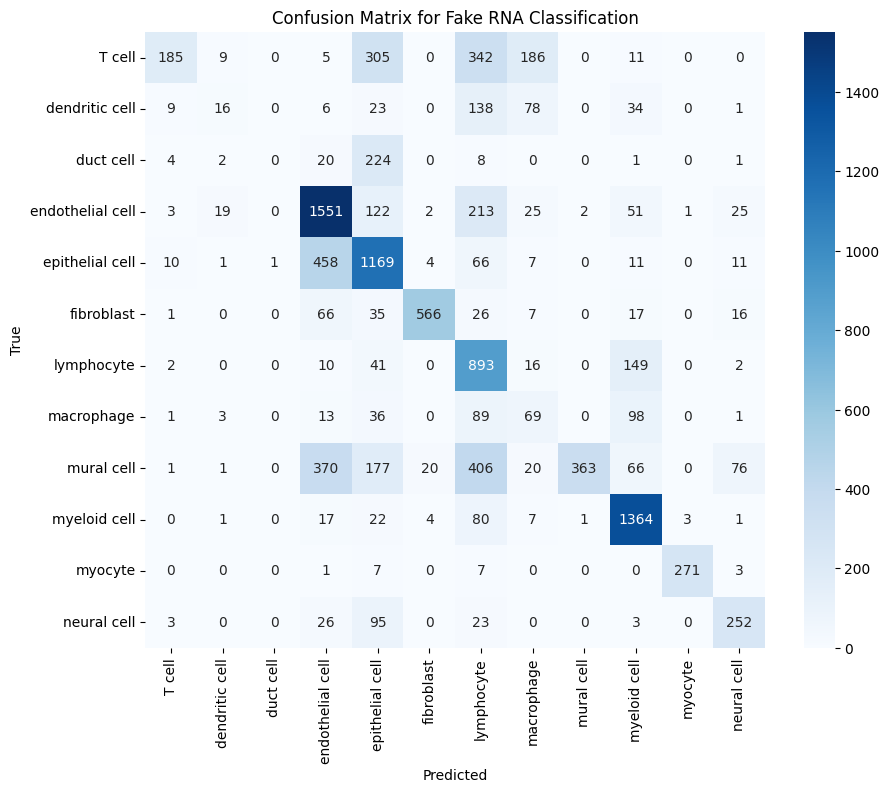

In [62]:
# Confusion matrix
cm = confusion_matrix(y_test_fake.values, y_pred_fake)

# Display confusion matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for Fake RNA Classification')
plt.show()


# Fine-tuning on scGEX

In [ ]:
model_gex = xgboost.XGBClassifier()
model_gex.load_model('best_xgb_model.json')

In [ ]:
model_gex.fit(X_train_gex, 
              y_train_gex,
              xgb_model=model_gex.get_booster(),  # Continue training from existing model
              verbose=True
              )

In [ ]:
y_pred_rna = model_gex.predict(X_test_rna)
print(f'Accuracy: {accuracy_score(y_test_rna.values, y_pred_rna):.4f}')

In [ ]:
y_pred_gex = model_gex.predict(X_test_gex)
print(f'Accuracy: {accuracy_score(y_test_gex.values, y_pred_gex):.4f}')

In [ ]:
y_pred_fake = model_gex.predict(X_test_fake)
print(f'Accuracy: {accuracy_score(y_test_fake, y_pred_fake):.4f}')

# Fine-tuning on generated scRNA

In [ ]:
model_fake = xgboost.XGBClassifier()
model_fake.load_model('best_xgb_model.json')

In [ ]:
model_fake.fit(X_train_fake, 
               y_train_fake,
               xgb_model=model_fake.get_booster(),  # Continue training from existing model
               verbose=True
               )

In [ ]:
y_pred_rna = model_fake.predict(X_test_rna)
print(f'Accuracy: {accuracy_score(y_test_rna.values, y_pred_rna):.4f}')

In [ ]:
y_pred_gex = model_fake.predict(X_test_gex)
print(f'Accuracy: {accuracy_score(y_test_gex.values, y_pred_gex):.4f}')

In [ ]:
y_pred_fake = model_fake.predict(X_test_fake)
print(f'Accuracy: {accuracy_score(y_test_fake, y_pred_fake):.4f}')

# Test on BREAST data

In [6]:
# Load breast data
rna = sc.read_h5ad(sriva+"RNA_filt_log_subset.h5ad")
gex = sc.read_h5ad(sriva+"GEX_filt_log_subset.h5ad")
fake = sc.read_h5ad(data+"breast_fake_RNA_PermInv_VAE_UNET.h5ad")

In [7]:
marker_genes = {'T cell': ['IL7R', 'CCL5', 'PTPRC', 'CXCR4', 'GNLY', 'CD2', 'SRGN'],
                'basal cell': ['KRT14', 'KRT17', 'DST', 'KRT5', 'SAA1', 'ACTA2', 'SFN'],
                'endothelial cell': ['SELE', 'ACKR1', 'FABP4', 'STC1', 'ANGPT2', 'CSF3'],
                'fibroblast': ['DCN', 'APOD', 'CFD', 'TNFAIP6', 'LUM', 'COL1A2', 'COL1A1'],
                'macrophage': ['HLA-DRA', 'IL1B', 'HLA-DPA1', 'HLA-DPB1', 'HLA-DRB1', 'CD74', 'CCL3']
              }

In [8]:
genes = []

for row in list(marker_genes.values()):
    for item in row:
        if item not in genes:
            genes.append(item)
            
# np.random.shuffle(genes)

In [9]:
df_rna = pd.DataFrame(index   = rna.obs.index,
                      columns = genes,
                      data    = rna.X[:, rna.var.feature_name.isin(genes)])

df_gex = pd.DataFrame(index   = gex.obs.index,
                      columns = genes,
                      data    = gex.X[:, gex.var.feature_name.isin(genes)])

df_fake = pd.DataFrame(index   = fake.obs.index,
                       columns = genes,
                       data    = fake.X[:, fake.var.feature_name.isin(genes)])

In [10]:
# Encode labels
label_encoder = LabelEncoder()
label_encoder.fit(rna.obs["cell_type"].values.tolist())
label_encoder.classes_

array(['T cell', 'basal cell', 'endothelial cell', 'fibroblast',
       'macrophage'], dtype='<U16')

In [11]:
df_rna["cell_type"]  = label_encoder.transform(rna.obs["cell_type"].values.tolist())
df_gex["cell_type"]  = label_encoder.transform(gex.obs["cell_type"].values.tolist())
df_fake["cell_type"] = label_encoder.transform(rna.obs["cell_type"].values.tolist())

In [12]:
# Create train-test split (final evaluation set)
X_train_rna, X_test_rna, y_train_rna, y_test_rna = train_test_split(df_rna[df_rna.columns[:-1]],
                                                                    df_rna[df_rna.columns[-1]],
                                                                    test_size=0.15,
                                                                    random_state=42,
                                                                    stratify=df_rna[df_rna.columns[-1]]
                                                                    )

In [13]:
# Create train-test split (final evaluation set)
X_train_gex, X_test_gex, y_train_gex, y_test_gex = train_test_split(df_gex[df_gex.columns[:-1]],
                                                                    df_gex[df_gex.columns[-1]],
                                                                    test_size=0.15,
                                                                    random_state=42,
                                                                    stratify=df_gex[df_gex.columns[-1]]
                                                                    )

In [14]:
# Create train-test split (final evaluation set)
X_train_fake, X_test_fake, y_train_fake, y_test_fake = train_test_split(df_fake[df_fake.columns[:-1]],
                                                                        df_fake[df_fake.columns[-1]],
                                                                        test_size=0.15,
                                                                        random_state=42,
                                                                        stratify=df_fake[df_fake.columns[-1]]
                                                                        )

# Training and hyperparameter setting xgboost on scRNA

In [15]:
# Define XGBoost classifier
xgb_clf = xgboost.XGBClassifier(objective='multi:softprob',
                                num_class=len(label_encoder.classes_),
                                device="cpu",
                                random_state=42)

In [16]:
# Hyperparameter grid
param_grid = {'booster': ['gbtree', 'dart'],
              'max_depth': [2, 4, 6],
              'learning_rate': [0.01, 0.05, 0.1],
              'n_estimators': [50, 100, 150],
              'subsample': [0.6, 0.8, 1.0],
              }

In [17]:
# Cross-validation and hyperparameter tuning
clf_cv = GridSearchCV(estimator=xgb_clf,
                      param_grid=param_grid,
                      scoring='accuracy',
                      cv=5,
                      verbose=1,
                      n_jobs=8)

clf_cv.fit(X_train_rna, y_train_rna)

Fitting 5 folds for each of 162 candidates, totalling 810 fits


: 

: 

: 

In [ ]:
# Best hyperparameters
print("Best hyperparameters:")
print(clf_cv.best_params_)

# Evaluate on final test set
best_model = clf_cv.best_estimator_

Best hyperparameters:


NameError: name 'clf_cv' is not defined

In [ ]:
best_model.save_model(home + "weights/breast_best_xgb_model.json")

# Performance evaluation on scRNA, scGEX, generated scGEX

In [ ]:
# y_pred_rna = model_rna.predict(X_train_rna)
# print(f'Accuracy: {accuracy_score(y_train_rna.values, y_pred_rna):.4f}')

Accuracy: 0.9961


In [ ]:
y_pred_rna = model_rna.predict(X_test_rna)

# Classification report
print("Classification Report:")
print(classification_report(y_test_rna.values, y_pred_rna, target_names=label_encoder.classes_))

Classification Report:
                  precision    recall  f1-score   support

          T cell       0.99      0.98      0.99      1043
  dendritic cell       0.87      0.88      0.87       305
       duct cell       0.86      0.61      0.71       260
endothelial cell       0.99      1.00      0.99      2014
 epithelial cell       0.93      0.97      0.95      1738
      fibroblast       0.99      0.98      0.99       734
      lymphocyte       0.98      0.98      0.98      1113
      macrophage       0.87      0.80      0.84       310
      mural cell       0.99      1.00      0.99      1500
    myeloid cell       0.98      0.99      0.99      1500
         myocyte       0.99      0.94      0.96       289
     neural cell       0.92      0.94      0.93       402

        accuracy                           0.97     11208
       macro avg       0.95      0.92      0.93     11208
    weighted avg       0.97      0.97      0.97     11208



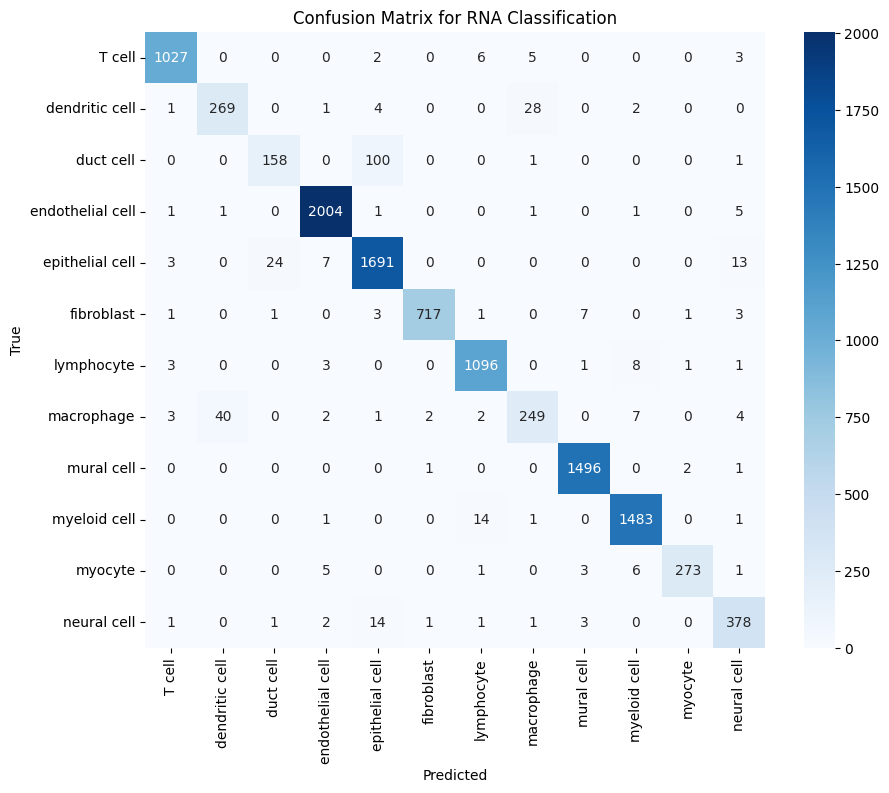

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test_rna.values, y_pred_rna)

# Display confusion matrix as a heatmap
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for RNA Classification')
plt.show()

In [ ]:
y_pred_gex = model_rna.predict(X_test_gex)

# Classification report
print("Classification Report for GEX:")
print(classification_report(y_test_gex.values, y_pred_gex, target_names=label_encoder.classes_))

Classification Report for GEX:
                  precision    recall  f1-score   support

          T cell       0.51      0.34      0.41      1043
  dendritic cell       0.38      0.16      0.23       305
       duct cell       0.71      0.12      0.21       260
endothelial cell       0.82      0.92      0.86      2014
 epithelial cell       0.61      0.67      0.64      1738
      fibroblast       0.68      0.76      0.72       734
      lymphocyte       0.66      0.50      0.56      1113
      macrophage       0.13      0.40      0.19       310
      mural cell       0.94      0.74      0.83      1500
    myeloid cell       0.85      0.04      0.08      1500
         myocyte       0.65      0.78      0.71       289
     neural cell       0.10      0.48      0.16       402

        accuracy                           0.56     11208
       macro avg       0.59      0.49      0.47     11208
    weighted avg       0.69      0.56      0.56     11208



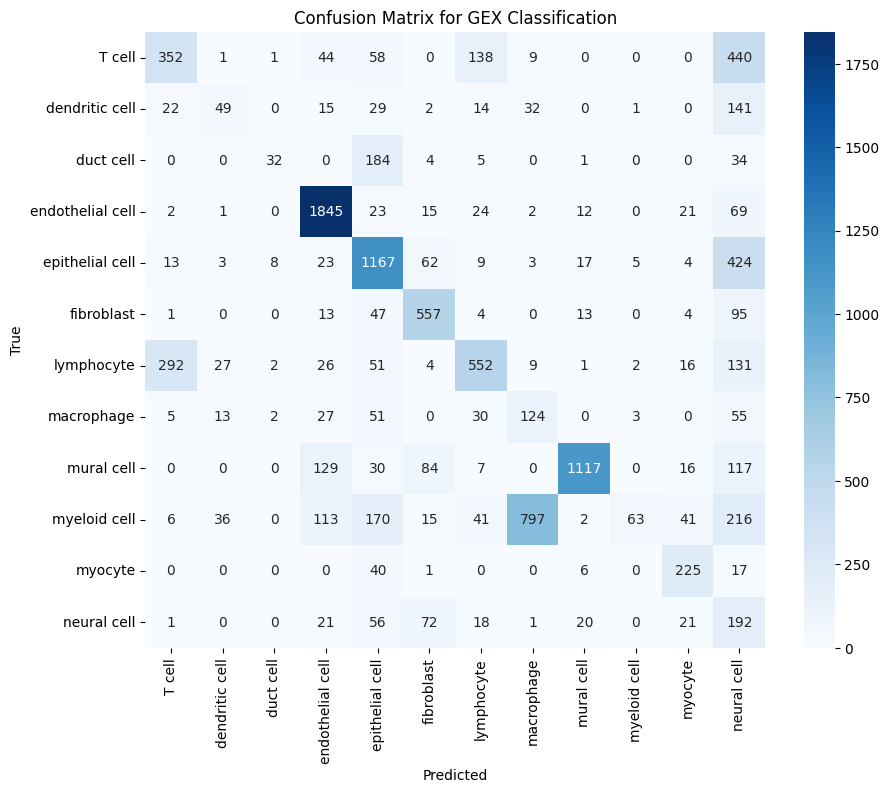

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test_gex.values, y_pred_gex)
# Display confusion matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for GEX Classification')
plt.show()

In [ ]:
y_pred_fake = model_rna.predict(X_test_fake)

# Classification report
print("Classification Report for GEX:")
print(classification_report(y_test_fake.values, y_pred_fake, target_names=label_encoder.classes_))

Classification Report for GEX:
                  precision    recall  f1-score   support

          T cell       0.84      0.18      0.29      1043
  dendritic cell       0.31      0.05      0.09       305
       duct cell       0.00      0.00      0.00       260
endothelial cell       0.61      0.77      0.68      2014
 epithelial cell       0.52      0.67      0.59      1738
      fibroblast       0.95      0.77      0.85       734
      lymphocyte       0.39      0.80      0.52      1113
      macrophage       0.17      0.22      0.19       310
      mural cell       0.99      0.24      0.39      1500
    myeloid cell       0.76      0.91      0.83      1500
         myocyte       0.99      0.94      0.96       289
     neural cell       0.65      0.63      0.64       402

        accuracy                           0.60     11208
       macro avg       0.60      0.52      0.50     11208
    weighted avg       0.66      0.60      0.57     11208



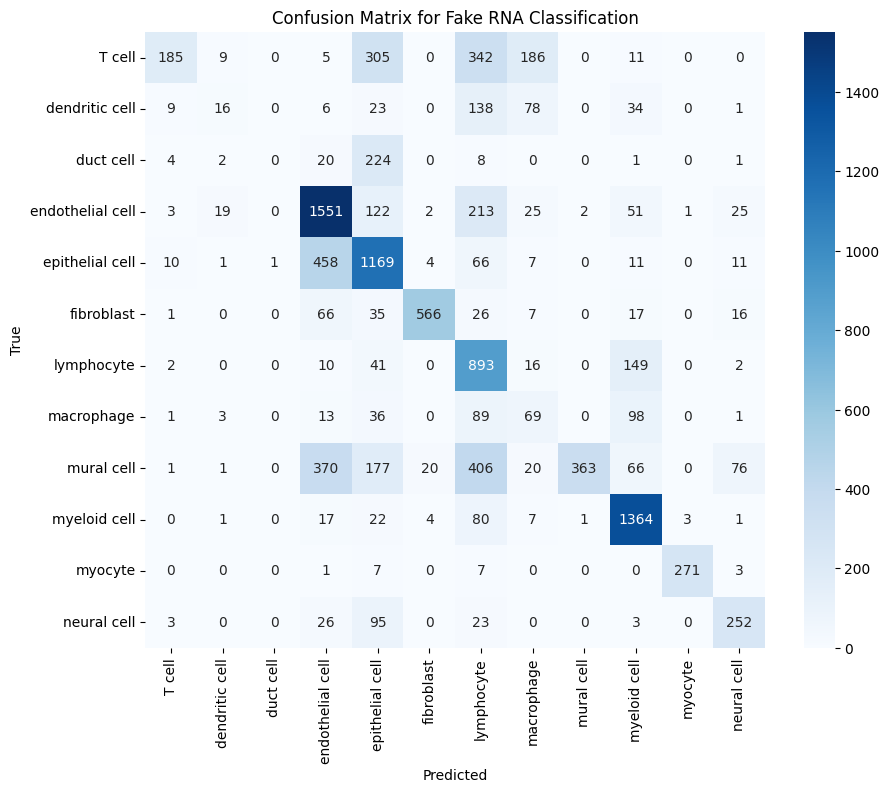

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test_fake.values, y_pred_fake)

# Display confusion matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for Fake RNA Classification')
plt.show()
